# NASDAQ-100 Microstructure: Backtest & Signal Evaluation

**Chapter 16 — Strategy Simulation**

This notebook translates Ch11–15 model outputs into backtested strategies for
the NASDAQ-100 microstructure case study: 15-minute decisions across the 113
stocks of the declared 115 that carry prices.
The backtest runs through the **ml4t-backtest engine** using 15-minute OHLCV
bars constructed from AlgoSeek TAQ trade prices — the same data that supports
position-level risk controls, realistic execution simulation, and proper cost
accounting in downstream chapters (Ch17–19).

1. **Plumbing test** — verify the engine pipeline produces no spurious alpha
2. **Parametric sweep** — test all (prediction × signal method) combinations
3. **Statistical analysis** — DSR, family comparison, IC-to-Sharpe relationship

Sections 1–2 generate new backtest results (write to registry). Section 3
is read-only — it queries the registry via `BacktestExplorer` and can be
re-run independently without re-running the sweep.

**Book Reference:** Chapter 16, Sections 16.4–16.8

**Prerequisites:** Completed model training (Ch11–15) for this case study.

In [1]:
"""Ch16 Backtest & Signal Evaluation — NASDAQ-100 Microstructure case study."""

import json
import sqlite3
import time

import polars as pl

from case_studies.research import (
    SUPERSEDES_LIVE,
    OfficialPopulation,
    open_study,
    population_supersedes,
    prediction_rows_at,
    published_population_names_at,
    reuse_disclosure,
    superseded_members_at,
)
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import (
    build_backtest_spec,
    serializable_backtest_spec,
    traded_universe_declaration,
)
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.ensemble import (
    ensemble_training_spec,
    load_ensemble_declaration,
    mean_forecast,
    resolve_members,
)
from case_studies.utils.notebook_contracts import (
    degenerate_prediction_hashes,
    excluded_families,
    prediction_members_in_force,
)
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
)
from case_studies.utils.registry.registration import (
    register_prediction_set,
    register_training_run,
)
from case_studies.utils.sweep_config import (
    get_entry_schemes_for,
    get_signal_passes_for,
    get_top_k_values_for,
    get_top_n_predictions,
    get_universe_filters_for,
)
from utils.paths import get_case_study_dir
from utils.style import show_with_alt

In [2]:
CASE_STUDY_ID = "nasdaq100_microstructure"
LABEL = ""
SPLIT = "validation"
# Zero means the smallest top_k from setup.yaml backtest.sweep.top_k_grid.
TOP_K = 0
MAX_SYMBOLS = 0
FORCE_REBACKTEST = False  # Set True to re-backtest even if a complete backtest_hash exists
TOP_N_PREDICTIONS = None
# Zero means every feasible entry scheme. A positive value keeps the first N, which is what makes
# a reduced run of this notebook finish in minutes: `backtest.sweep.signal_nasdaq100` crosses two
# selection methods, three quantiles, two directions, three slot counts, two hold windows and two
# signal-exit thresholds, and 42 of those combinations are feasible on this panel. A backtest of
# this panel was measured at 31.8 s on 2026-09-11, so the full 45 arms is about 34 minutes for a
# single prediction set. The same lever as `MAX_RISK_VARIANTS` in 16 and `MAX_COST_POINTS` in the
# cost notebooks. Truncating the list keeps the canonical equal-weight arms, which are what
# `signal_passes.baseline_schemes` names, so a reduced run still completes pass 1.
MAX_ENTRY_SCHEMES = 0
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace - `_declares_tier_and_workspace` in `tests/pm_helpers.py`
# looks for exactly this pair. Without them the canonical branch regenerates in place, which
# needs generated-artifact symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

## 1. Setup & Plumbing Test

Before the sweep, check the machinery on a signal that carries no information.
Replacing the predictions with random scores and running the same engine should
not produce a profitable strategy. If it does, the profit came from the
pipeline rather than the signal - a lookahead in the fill timing, a misaligned
join, a cost model that never charges.

The check is one-sided. Random trading pays the spread on every rebalance
without any compensating edge, so a clearly negative result is the expected
outcome and not a failure. What would fail is profit that persists after
costs.

The study is opened before anything resolves a path or reads the registry. Opening it
activates a root and rewrites `ML4T_OUTPUT_DIR` process-wide, and every later
`get_case_study_dir`, prediction index and registry write resolves against that variable. A
`CASE_DIR` bound before this line points at the released registry while the sweep writes to
the workspace, and the two never meet: the sweep finds nothing registered and every reader
scoped to hashes from the other root comes back empty.

In [3]:
study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "signal")

if not LABEL:
    LABEL = bt_config.primary_label

print(
    f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""",
    flush=True,
)
if excluded_families(CASE_STUDY_ID):
    print(
        "Active-model filter: excluding "
        f"{', '.join(sorted(excluded_families(CASE_STUDY_ID)))} pending corrected reruns",
        flush=True,
    )

=== Protocol Term Sheet ===
  Case study:    nasdaq100_microstructure
  Label:         fwd_ret_15m
  Calendar:      NYSE
  Cadence:       15_minute
  Commission:    5.0 bps
  Slippage:      2.0 bps
  Total cost:    7.0 bps/leg
  Long/short:    True



In [4]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)

# `MAX_SYMBOLS` reduces the price panel, and until the run says so in its own specification
# that reduction did not reach `backtest_hash`: a reduced run and the full run over the same
# predictions hashed alike, so the second was served the first's result and the reduction
# bought nothing (ml4t/agent-workspace#911). Declaring it here, before anything is hashed,
# gives a reduced run an identity of its own; `run_backtest` checks the panel against the
# declaration and narrows the predictions to it, so the sweep ranks the cross-section this
# says it ranks and `n_assets` above describes that same set. A full run declares nothing and
# is byte-identical to before.
# A reduced run is a preview run. Refused on the canonical tier so a narrowed result can
# never land in the registry the book's numbers come from, and so the two can never sit in
# one registry to be ranked against each other: `resolve_best_predictions` takes MAX(sharpe)
# over every backtest of a prediction, and a Sharpe earned over a handful of names would
# advance a configuration ahead of one earned over the whole panel. `us_equities_panel` 16
# through 19 already refuse the parameter this way, and `canonically_refused_parameters`
# reads the refusal out of the source, so the canonical fixture path drops the name rather
# than handing the notebook something its first cell raises on.
if EXECUTION_TIER == "canonical" and MAX_SYMBOLS:
    raise ValueError(
        "MAX_SYMBOLS narrows the universe this run trades, which makes it a different "
        "portfolio from the declared one and gives it its own backtest identity "
        "(ml4t/agent-workspace#911). A canonical run trades the declared universe: set "
        "MAX_SYMBOLS=0, or run under EXECUTION_TIER='preview' with a WORKSPACE."
    )
TRADED_UNIVERSE = traded_universe_declaration(prices) if MAX_SYMBOLS else None

n_assets = prices["symbol"].n_unique()
if TOP_K == 0:
    _feasible_top_k = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
    if not _feasible_top_k:
        raise ValueError(
            f"top_k_grid for {LABEL!r} in {CASE_STUDY_ID} has no value < "
            f"n_assets={n_assets}; declare a feasible k in setup.yaml"
        )
    TOP_K = _feasible_top_k[0]
print(f"Prices: {len(prices):,} rows, {n_assets} assets; plumbing-test TOP_K={TOP_K}", flush=True)

Prices: 10,069,951 rows, 113 assets; plumbing-test TOP_K=5


In [5]:
strategy_spec = build_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    prices=prices,
    traded_universe=TRADED_UNIVERSE,
    prediction_hash="plumbing_test",
    initial_cash=bt_config.initial_cash,
    chapter="ch16",
    # The cadence is per-label here (setup.yaml::decision.cadence_by_label), so a spec
    # built without one would be built against a default no run uses.
    label=LABEL,
    signal={
        "method": "score_weighted_top_k",
        "top_k": TOP_K,
        "long_short": bt_config.long_short,
    },
)

try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        strategy_spec,
        top_k=TOP_K,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )

    status = "FAIL" if random_sharpe > 1.5 else "PASS"
    print(f"Random signal Sharpe: {random_sharpe:.3f}  [{status}]", flush=True)

    if random_sharpe > 1.5:
        print("WARNING: Random signal produces positive Sharpe — investigate pipeline", flush=True)
    elif random_sharpe < -1.5:
        print(
            "NOTE: Strongly negative random Sharpe reflects turnover drag under quote-aware costs",
            flush=True,
        )
except ValueError as e:
    if "zero variance" in str(e).lower():
        print(f"Plumbing test skipped: {e} (too few assets for meaningful test)", flush=True)
        random_sharpe = 0.0
    else:
        raise

Random signal Sharpe: -29.508  [PASS]


NOTE: Strongly negative random Sharpe reflects turnover drag under quote-aware costs


## 2. The Signal Sweep

Every combination of prediction and entry scheme below runs through the same
`run_backtest()` call as a one-off backtest would, so the sweep and a single
backtest cannot diverge.

The sweep runs in two passes. The first trades every prediction three ways -
equal weight over the top 5, 10 and 20 names - on the cost-feasible universe,
which is the universe the strategy this chapter ends on actually trades. The
second takes the predictions that scored highest in the first and asks what the
entry mechanism does to them, across the slot grid declared in
`backtest.sweep.signal_nasdaq100`. The same three equal-weight arms are also run
without the cost screen, on those same predictions: that unscreened pair is what
Section 3 reads.

Ranking over the whole universe is the naive approach the feasibility analysis
warned against, and it is kept here as the comparison rather than as the main
grid. The ordering will often place its strongest views on the least liquid
names in the panel, and at this rebalancing frequency each of those positions is
entered and exited repeatedly.

The sweep also separates two things that are easily conflated: how well a
prediction orders the cross-section, and how much trading that ordering
provokes. A prediction whose scores change sharply from bar to bar produces
more position changes than one whose scores move smoothly, at the same
ordering quality. The cost of those changes is charged here and not in any
score.

A grid cell is skipped when its identity is already registered or already
queued by this sweep. Two schemes can resolve to one identity - a backtest is
defined by what it computes, not by the label its scheme carries - and without
the queued half of that test the first computes the result while the second
reuses its cache and is still counted as work done, so the sweep reports more
backtests than the registry holds.

In [6]:
pred_index = load_prediction_index(
    CASE_STUDY_ID,
    label=LABEL,
    split=SPLIT,
)
if not pred_index.is_empty():
    # Exclude causal_dml (not a trading signal) and the synthetic ensemble
    # forecast — the ensemble is a cost-feasible-universe construct introduced
    # in Section 4 (Act 2), not part of the full-universe baseline sweep.
    pred_index = pred_index.filter(~pl.col("family").is_in(["causal_dml", "ensemble"]))

if pred_index.is_empty():
    msg = f"No predictions found for {CASE_STUDY_ID}/{LABEL}/{SPLIT}"
    raise RuntimeError(msg)

# `load_prediction_index` answers "what predictions exist in this registry" and leaves
# admissibility to the caller. A backtest is asking a different question - "what should
# I trade" - and the difference is exactly the conditions the catalog computes. Without
# this filter the sweep consumes rows the official population cannot contain: a run that
# reports every backtest completed and zero failed, off a population that resolves empty.
# That is not a late failure, it is a loud success on the wrong rows, and it costs the
# full sweep to discover.
# `complete` is the whole test: the catalog already requires a current identity before a row
# can be complete, and the tier is decided by which registry the rows were read from, not by
# a column comparison. Re-asserting either here would reject a preview run's own rows.
# The catalog is read off `CASE_DIR`, the directory `load_prediction_index` just read, and
# not by opening a `Study`: every `Study.open` branch ends in `activate()`, which would both
# answer for a different registry than the one being filtered and re-point the rest of the
# notebook - including where `run_backtest(register=True)` writes - at the activated root.
_catalog = prediction_rows_at(CASE_DIR)
# `complete` does not answer supersession, and the two look like the same question. A row is
# complete when its artifacts and fold metrics are present, and `identity_status == "current"`
# only says the registry still understands the schema it was written under. Neither moves when
# a model notebook refits: the retired generation's rows stay complete and current, and a sweep
# selecting on the catalog alone runs over both generations at once. It does not fail - it
# succeeds over twice the population and freezes the mixture into every backtest downstream.
#
# Measured against this registry on 2026-09-11: it records one supersedes edge, on
# `nasdaq100_microstructure-linear-validation-v1`. That name's retired generation lists 61
# prediction identities and its generation in force shares none of them, because a refit moves
# every hash. None of the 61 is in the catalog, so this join removes nothing today, and every
# one of the catalog's rows belongs to some declared population.
#
# A no-op is what this filter looks like whenever a refit takes the rows it retired out of the
# catalog with it, which is what the linear refit did. It stops being one the first time a
# generation is retired while its rows stay - and nothing here guarantees which of the two a
# given refit will be, which is the reason to hold the join rather than to decide per refit.
_retired = superseded_members_at(CASE_DIR)
_admissible = _catalog.filter(
    pl.col("complete") & ~pl.col("prediction_hash").is_in(list(_retired))
).select("prediction_hash")
_offered = len(pred_index)
_offered_hashes = set(pred_index["prediction_hash"])
pred_index = pred_index.join(_admissible, on="prediction_hash", how="inner")
if pred_index.is_empty():
    msg = (
        f"{_offered} prediction sets exist for {CASE_STUDY_ID}/{LABEL}/{SPLIT} but none is "
        "admissible. Either every row is missing an artifact or a fold metric, or carries an "
        "identity this schema version no longer recognises; or every row belongs to a "
        f"generation its own name has moved past ({len(_retired)} identities in this registry "
        "are retired that way). Backtesting them would produce a full sweep over a population "
        "that cannot be official. Re-run the model notebooks on the research interface first."
    )
    raise RuntimeError(msg)
if len(pred_index) < _offered:
    # Two conditions were tested and they call for different work, so they are counted apart: an
    # incomplete row needs its own fit finished, a superseded one needs nothing - it is a
    # retired generation and the sweep is right to leave it. Supersession is named first because
    # it decides the row on its own; completing a retired row would not readmit it.
    _dropped = _offered_hashes - set(pred_index["prediction_hash"])
    _dropped_superseded = len(_dropped & _retired)
    print(
        f"  Excluded {len(_dropped)} of {_offered} prediction sets: "
        f"{len(_dropped) - _dropped_superseded} not complete, "
        f"{_dropped_superseded} superseded by a later generation of their own population",
        flush=True,
    )

# Membership, and it runs here rather than beside the exclusion above for two reasons
# that are easy to get wrong. The admissibility refusal has to stay reachable: a pool
# emptied by the catalog filter must raise the error naming incompleteness and
# supersession, not this one, which would report an empty pool as unpublished. And the
# _dropped accounting above splits its exclusions into two counts by subtracting what
# survives, so a membership drop landing before it would be counted as not complete.
#
# Membership is a different set from the exclusion above, and the weaker one is what
# this sweep had (ml4t/agent-workspace#1088). "Not retired" admits a
# prediction no population ever listed - an experiment its case study never published is
# retired by nobody - while "published" does not. `published_members_at` subtracts the
# retired set itself, so this is never the looser test; it is the same shape
# `sp500_equity_option_analytics/14_backtest:292` already applies, and running the nine
# on two different rules is the thing worth removing even where the answer agrees.
#
# The two rules agree on the publication question here - the registry publishes 784
# prediction sets and holds 784 - but do not read that as the filter being inert. Measured
# on the 2026-09-13 canonical run, it narrowed the pool in two steps and both bit:
#
#     220 of 784 members dropped for covering less of the cross-section than their
#         feature panels offered them
#     564 prediction sets in the populations in force
#     80 further sets excluded on this label as complete, not retired, and published
#         by no population in force
#     162 predictions swept
#
# The first named drop was a `deep_learning/lstm_h64` set carrying 81.2% of the (entity,
# session) pairs its input panel offered it. Without this filter the previous sweep's
# pass-2 eight was four `nlinear` checkpoints at 67.4% coverage and four L1-linear sets
# that are constants - two distinct forecast values across 8,006,995 rows - so 180 of its
# 360 mechanism backtests priced a 45-arm entry grid over predictions that rank nothing.
#
# `None` means the registry declares no populations at all - a fixture, or a clean clone -
# and there is then nothing to filter against. Left unscoped in that case rather than
# narrowed to nothing, which is what `prediction_members_in_force` returns `None` to say.
#
# It is slow, and silently so: it opens every published member's artifact to check symbol
# coverage, which on this registry is 784 parquet files totalling 94.3 GB. Measured on the
# 2026-09-13 canonical run at **8,608 s - 2 h 23 m, 11.0 s per member** - before the
# sweep's first backtest, with nothing printed while it runs because every print in this
# cell comes after the call returns. That is the cost of the check rather than a hang, and
# it is said here because the next reader watching a quiet log is the one who needs to
# know. It is also label-agnostic: it coverage-checks every published member whatever the
# caller is sweeping, so two thirds of those reads are for labels this run never touches.
# Scoping it to the candidates the caller can act on is a change to the shared helper and
# not to this notebook, which is why it is described here rather than made here.
_members, _population_notes = prediction_members_in_force(study, CASE_DIR)
for _note in _population_notes:
    print(f"  {_note}", flush=True)
if _members is not None:
    print(f"  {len(_members):,} prediction sets in the populations in force", flush=True)
    _before_membership = set(pred_index["prediction_hash"])
    pred_index = pred_index.filter(pl.col("prediction_hash").is_in(list(_members)))
    _unpublished = _before_membership - set(pred_index["prediction_hash"])
    if _unpublished:
        print(
            f"  Excluded {len(_unpublished)} further prediction sets that are complete and "
            "not retired but that no population in force publishes",
            flush=True,
        )
    if pred_index.is_empty():
        msg = (
            f"{len(_before_membership)} prediction sets for {CASE_STUDY_ID}/{LABEL}/{SPLIT} "
            "are complete and not retired, and no population in force publishes any of "
            f"them. The registry publishes {len(_members):,} prediction identities under "
            f"{len(published_population_names_at(CASE_DIR))} population names; this label's "
            "rows are in none of them, so the model notebook that wrote them registered "
            "them outside the population mechanism. Re-run it before sweeping."
        )
        raise RuntimeError(msg)

# The pool the sweep is entitled to draw on, captured HERE: after the membership and
# coverage filter above, and before the preview truncation below. The ensemble reads it
# rather than the catalog-level `_admissible`, which is only "complete and not retired"
# and so predates both. Captured before the truncation because `TOP_N_PREDICTIONS` narrows
# what a preview run *sweeps*, not what the case study is allowed to average.
SWEPT_POOL = set(pred_index["prediction_hash"])

if TOP_N_PREDICTIONS > 0:
    pred_index = pred_index.head(TOP_N_PREDICTIONS)

n_predictions = len(pred_index)
print(f"Predictions to sweep: {n_predictions}", flush=True)
ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
print(
    f"  IC range: {ic_min:.4f} — {ic_max:.4f}"
    if ic_min is not None
    else "  IC range: not yet computed",
    flush=True,
)

  220 member(s) were dropped from the candidate pool for covering less than the cross-section their feature panels offered them: 007e8fb4ae90 nasdaq100_microstructure/fwd_ret_5m/validation deep_learning/lstm_h64: 6736848 of 9874850 declared (entity, session) pairs (68.2%) across 113 entities; of the 8299430 its input panel offered it carries 6736848 (81.2%) - 3138002 missing; 00cf4acb2592 nasdaq100_microstructure/fwd_ret_15m/validation deep_learning/nlinear: 6478166 of 9615648 declared (entity, session) pairs (67.4%) across 113 entities; of the 8039984 its input panel offered it carries 6478166 (80.6%) - 3137482 missing; 02454301bca8 nasdaq100_microstructure/fwd_ret_15m/validation deep_learning/tcn: 6478166 of 9615648 declared (entity, session) pairs (67.4%) across 113 entities; of the 8039984 its input panel offered it carries 6478166 (80.6%) - 3137482 missing; 02f4e3bd6d2d nasdaq100_microstructure/fwd_ret_5m/validation deep_learning/tcn: 6736848 of 9874850 declared (entity, session) 

  564 prediction sets in the populations in force


  Excluded 80 further prediction sets that are complete and not retired but that no population in force publishes


Predictions to sweep: 162


  IC range: 0.0008 — 0.0091


In [7]:
entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID, LABEL, n_assets, long_short=bt_config.long_short
)
if MAX_ENTRY_SCHEMES:
    entry_schemes = entry_schemes[:MAX_ENTRY_SCHEMES]

# The universe axis, and which arms are crossed with which of its values.
#
# `backtest.sweep.universe_filter` declares `cost_feasible` here, and `universe.cost_feasible`
# names the 50 validation and 50 holdout symbols `apply_universe_filter` restricts to. Nothing
# in this notebook read either: every registered spec omitted `signal.universe_filter`, so
# `BacktestExplorer` defaulted all of them to "full". Act 1 worked by that accident, and the
# two readers that ask for the declared value got nothing - Section 4 below printed an empty
# table and exited 0, `17_costs` priced nothing and exited 0, and only `20_strategy_analysis`
# failed. Measured 2026-09-09: 202 signal backtests registered, 0 carrying the key.
_declared_universes = [u for u in get_universe_filters_for(CASE_STUDY_ID) if u]
universe_filters: list[str | None] = [None, *_declared_universes]

# The grid is walked in two passes, declared under `backtest.sweep.signal_passes`.
#
# Crossing every arm with every universe over every prediction is what this cell used to
# build, and on this case study that is 741 prediction sets × 117 arms × 2 universes =
# 173,394 backtests. One backtest of this panel was measured at 31.8 s on 2026-09-11, which
# puts the cross-product at about 1,500 hours. No other case study in the book declares more
# than four entry schemes or more than one universe.
#
# Pass 1 asks which predictions are worth studying, on three equal-weight concentrations and
# on the universe the carrier trades. Pass 2 asks what the entry mechanism does to them, and
# asks it only of the predictions pass 1 ranked highest. The two questions have different
# widths, and one cross-product answered both at the width of the wider one.
_passes = get_signal_passes_for(CASE_STUDY_ID)
_by_name = {s["name"]: s for s in entry_schemes}

if _passes is None:
    # No plan declared: the full cross-product, which is what every other case study runs.
    baseline_arms = [(s, u) for u in universe_filters for s in entry_schemes]
    mechanism_arms: list[tuple[dict, str | None]] = []
    mechanism_top_n = 0
else:
    _missing = [n for n in _passes["baseline_schemes"] if n not in _by_name]
    if _missing and not MAX_ENTRY_SCHEMES:
        # Checked only when the scheme list is the full declared one. A preview run truncates
        # `entry_schemes` and is expected to lose names; a canonical run that loses one has a
        # typo in `signal_passes`, and it would otherwise rank nothing, select nothing, and
        # report a completed sweep.
        msg = (
            f"backtest.sweep.signal_passes.baseline_schemes names {_missing}, which "
            f"get_entry_schemes_for does not produce for {LABEL}. Arms it does produce: "
            f"{sorted(_by_name)[:8]}"
        )
        raise KeyError(msg)
    _baseline_names = [n for n in _passes["baseline_schemes"] if n in _by_name]
    baseline_arms = [(_by_name[n], _passes["baseline_universe"]) for n in _baseline_names]
    mechanism_arms = [
        (s, _passes["baseline_universe"]) for s in entry_schemes if s["name"] not in _baseline_names
    ]
    # The reference universe carries the canonical concentrations only. It is what `17_costs`
    # reads for its full-vs-screened comparison and what Act 1 below reads for the unscreened
    # baseline. It is not a second copy of the sweep.
    mechanism_arms += [
        (_by_name[n], _passes["reference_universe"])
        for n in _passes["reference_schemes"]
        if n in _by_name
    ]
    mechanism_top_n = _passes["mechanism_top_n"]

print(f"\nEntry schemes ({len(entry_schemes)}):", flush=True)
for es in entry_schemes:
    print(f"  {es['name']}: {es['method']} (top_k={es.get('top_k', '-')})", flush=True)
print(
    "Universes: " + ", ".join("full" if u is None else str(u) for u in universe_filters),
    flush=True,
)

n_pass2_predictions = min(mechanism_top_n, n_predictions) if mechanism_arms else 0
n_pass1 = n_predictions * len(baseline_arms)
n_pass2 = n_pass2_predictions * len(mechanism_arms)
total_backtests = n_pass1 + n_pass2
print(
    f"\nPass 1 (baseline): {n_predictions} predictions × {len(baseline_arms)} arms "
    f"= {n_pass1} backtests",
    flush=True,
)
print(
    f"Pass 2 (mechanism): top {n_pass2_predictions} by pass-1 Sharpe × "
    f"{len(mechanism_arms)} arms = {n_pass2} backtests",
    flush=True,
)
print(f"Total grid: {total_backtests} backtests", flush=True)


Entry schemes (45):


  ew_top5: equal_weight_top_k (top_k=5)


  ew_top10: equal_weight_top_k (top_k=10)


  ew_top20: equal_weight_top_k (top_k=20)


  slot_l_lq90_s5_h120_noexit_b210: slot_persistent_signal_exit (top_k=-)


...

  ewtopk_ls_k20: equal_weight_top_k (top_k=20)


Universes: full, cost_feasible



Pass 1 (baseline): 162 predictions × 3 arms = 486 backtests


Pass 2 (mechanism): top 8 by pass-1 Sharpe × 45 arms = 360 backtests


Total grid: 846 backtests


In [8]:
t0 = time.time()
tally = {"completed": 0, "skipped": 0, "failed": 0}
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
# Identities already registered, plus the ones this sweep has queued. Both mean
# "running this grid cell would add nothing", which is what the skip test needs.
planned = set(existing_hashes)
print(f"Existing signal-stage hashes in registry: {len(existing_hashes):,}", flush=True)


def run_arms(rows, arms, pass_name):
    """Run one pass: every arm in `arms` against every prediction in `rows`.

    Both passes walk the same loop, so what separates them is only which
    predictions and which arms they are handed. A pass that is given no arms
    returns nothing rather than raising: a preview run truncates the scheme list
    and can legitimately leave pass 2 empty.
    """
    out = []
    n_cells = len(rows) * len(arms)
    if not n_cells:
        print(f"\n{pass_name}: no grid cells", flush=True)
        return out
    print(
        f"\n{pass_name}: {len(rows)} predictions × {len(arms)} arms = {n_cells} cells", flush=True
    )

    for i, pred_row in enumerate(rows.iter_rows(named=True)):
        pred_hash = pred_row["prediction_hash"]
        source = pred_row["source"]
        ic_mean = pred_row["ic_mean"]

        pending_schemes = []

        for j, (scheme, universe) in enumerate(arms):
            idx = i * len(arms) + j + 1

            signal = {
                "method": scheme["method"],
                "top_k": scheme.get("top_k", 20),
                "long_short": bt_config.long_short,
            }
            signal.update({k: v for k, v in scheme.items() if k not in ("name", "method")})
            # Only when a filter is declared. A `None` written into the spec is not the same as
            # an absent key: it would move `backtest_hash` for every row registered before this
            # axis existed, and `get_universe_filters_for` normalizes "full" and "none" to None
            # for that reason.
            if universe is not None:
                signal["universe_filter"] = universe
            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                traded_universe=TRADED_UNIVERSE,
                prediction_hash=pred_hash,
                initial_cash=bt_config.initial_cash,
                chapter="ch16",
                label=LABEL,
                signal=signal,
            )
            backtest_hash = backtest_hash_from_parts(pred_hash, serializable_backtest_spec(spec))

            if backtest_hash in planned:
                # Recorded, not just counted. A skipped cell is a cell of this pass whose
                # result is already in the registry, and pass 2 ranks on the pass-1 cells
                # rather than on the subset this invocation happened to compute.
                tally["skipped"] += 1
                out.append(
                    {
                        "prediction_hash": pred_hash,
                        "source": source,
                        "family": pred_row["family"],
                        "config_name": pred_row["config_name"],
                        "ic_mean": ic_mean,
                        "signal_method": scheme["name"],
                        "universe": "full" if universe is None else universe,
                        "pass": pass_name,
                        "backtest_hash": backtest_hash,
                        "ran": False,
                        # The metrics of a skipped cell are in the registry, not here, and
                        # the two halves of `out` have to share a schema for polars to
                        # build one frame from them.
                        "sharpe": None,
                        "total_return": None,
                        "max_drawdown": None,
                        "cagr": None,
                        "volatility": None,
                        "num_trades": None,
                        "failure": None,
                    }
                )
                continue
            planned.add(backtest_hash)
            pending_schemes.append((idx, scheme, universe, spec))

        if not pending_schemes:
            continue

        predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, pred_hash))

        for idx, scheme, universe, spec in pending_schemes:
            record = {
                "prediction_hash": pred_hash,
                "source": source,
                "ic_mean": ic_mean,
                "family": pred_row["family"],
                "config_name": pred_row["config_name"],
                "signal_method": scheme["name"],
                "universe": "full" if universe is None else universe,
                "pass": pass_name,
                "ran": True,
            }
            try:
                result = run_backtest(
                    CASE_STUDY_ID,
                    pred_hash,
                    spec,
                    prices=prices,
                    predictions=predictions,
                    label=LABEL,
                    register=True,
                    force_rebacktest=FORCE_REBACKTEST,
                    initial_cash=bt_config.initial_cash,
                    calendar=bt_config.calendar,
                )
                record.update(
                    backtest_hash=result.backtest_hash,
                    sharpe=result.metrics["sharpe"],
                    total_return=result.metrics["total_return"],
                    max_drawdown=result.metrics["max_drawdown"],
                    cagr=result.metrics.get("cagr", 0.0),
                    volatility=result.metrics.get("volatility", 0.0),
                    num_trades=result.metrics["num_trades"],
                    failure=None,
                )
                tally["completed"] += 1
                if result.backtest_hash:
                    existing_hashes.add(result.backtest_hash)
                    planned.add(result.backtest_hash)
            except Exception as exc:  # noqa: BLE001 - one cell must not end the sweep
                # Say what threw and which cell it was. A counter the log never
                # expands is how 144 of 360 pass-2 cells failed on `fwd_ret_5m`
                # while the run exited 0 and label coverage reported ok: every
                # one of them was a constant-forecast prediction meeting a slot
                # arm that cannot rank it, and nothing on the way out said so.
                # `record` already carries the family, config and arm, so the
                # message identifies the cell rather than only the exception.
                tally["failed"] += 1
                print(
                    f"  FAILED [{idx}/{n_cells}] {record['family']}/{record['config_name']} "
                    f"{record['signal_method']} on {record['universe']} "
                    f"(pred {pred_hash[:12]}): {type(exc).__name__}: {exc}",
                    flush=True,
                )
                record.update(
                    backtest_hash=None,
                    sharpe=None,
                    total_return=None,
                    max_drawdown=None,
                    cagr=None,
                    volatility=None,
                    num_trades=None,
                    failure=f"{type(exc).__name__}: {exc}",
                )
            out.append(record)

            if idx % 20 == 0 or idx == n_cells:
                elapsed = time.time() - t0
                rate = idx / elapsed if elapsed > 0 else 0
                print(
                    f"  [{idx}/{n_cells}] {elapsed:.0f}s ({rate:.1f} bt/s) | "
                    f"completed: {tally['completed']} skipped: {tally['skipped']} "
                    f"failed: {tally['failed']}",
                    flush=True,
                )
    return out


baseline_results = run_arms(pred_index, baseline_arms, "Pass 1 (baseline)")

Existing signal-stage hashes in registry: 3,762



Pass 1 (baseline): 162 predictions × 3 arms = 486 cells


### Which predictions pass 2 studies

The mechanism grid runs on the predictions that scored highest in pass 1, and
on nothing else. The ranking is by pass-1 validation Sharpe.

Not by information coefficient. `load_prediction_index` returns its rows
ordered by `ic_mean` descending, so taking the head of it - which is what
`top_n_predictions.signal` would do - would let a rank correlation decide which
models are backtested at all. A rank correlation and a traded result disagree
whenever turnover differs between two predictions of the same ordering quality,
which is the whole subject of this chapter. Every case study in the book
declares `signal: 0` for that reason.

What this does inherit from pass 1 is pass 1's own arbitrariness: the three
equal-weight concentrations are one way to trade a prediction, and a prediction
that suits the slot mechanism but not equal weight will not reach pass 2. That
is a property of a two-pass design and not of this particular grid, and it is
the price of not running the cross-product.

In [9]:
# The Sharpe comes from the registry and not from `baseline_results`, although pass 1 just
# produced both. A cell whose identity was already registered is skipped rather than re-run -
# that is what makes this sweep resumable - and a skipped cell computes no metrics for this
# invocation to hold. Ranking on what this invocation computed would therefore rank on
# whatever pass 1 had left to do: the whole pass on a first run, a fragment of it after an
# interruption, and nothing at all on a re-run of a finished sweep, which would silently move
# the selection or empty it. The registry holds every pass-1 cell either way.
#
# Built from the two hash fields under an explicit schema rather than from the records
# whole. `pl.DataFrame` infers a schema from the first 100 rows, the metric columns of a
# skipped record are all null, and a run that skips its first hundred cells and then
# computes one would hand a float to a column inferred as Null and fail at construction -
# before the `.select` that discards those columns ever runs. Resuming a long sweep is
# exactly the case that orders the records that way.
_cells = pl.DataFrame(
    [
        {"prediction_hash": r["prediction_hash"], "backtest_hash": r["backtest_hash"]}
        for r in baseline_results
    ],
    schema={"prediction_hash": pl.String, "backtest_hash": pl.String},
    orient="row",
).drop_nulls()
pass2_index = pred_index.head(0)
if mechanism_arms and not _cells.is_empty():
    _conn = sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db"))
    _metrics = pl.read_database(
        "SELECT backtest_hash, sharpe FROM backtest_metrics",
        connection=_conn,
        schema_overrides={"sharpe": pl.Float64},
    )
    _conn.close()
    # `drop_nulls` is the complete test here, and only because the Sharpe crosses SQLite.
    # A ruined path writes `float("nan")` for every ranking metric
    # (`backtest_runner.RUIN_UNRANKABLE_METRICS`), and a NaN read back into polars would
    # survive `drop_nulls` and then sort AHEAD of every finite Sharpe under
    # `descending=True`, so a bankrupt strategy would take a pass-2 slot. SQLite has no
    # NaN: it stores one as NULL, which is what makes the null test sufficient. Read the
    # scores from anywhere but the registry and this line needs `is_finite` as well.
    _scored = _cells.join(_metrics, on="backtest_hash", how="inner").drop_nulls("sharpe")
    if not _scored.is_empty():
        _ranked = (
            _scored.group_by("prediction_hash")
            .agg(best_sharpe=pl.col("sharpe").max())
            .sort("best_sharpe", descending=True)
            .head(mechanism_top_n)
        )
        pass2_index = pred_index.join(
            _ranked.select("prediction_hash"), on="prediction_hash", how="inner"
        )
        print(
            _ranked.join(
                pred_index.select("prediction_hash", "source", "family"),
                on="prediction_hash",
                how="left",
            ).select("source", "family", "best_sharpe")
        )

if mechanism_arms and pass2_index.is_empty():
    # Pass 1 registered no metric for any of its cells, so pass 2 has nothing to select and
    # would run over an empty frame while the sweep reported success.
    msg = (
        f"pass 1 ran {len(_cells)} grid cells for {LABEL} and the registry holds a Sharpe "
        "for none of them, so the mechanism grid has nothing to select. Either every "
        "pass-1 backtest failed, or the metrics were written to a different registry than "
        f"{CASE_DIR / 'run_log' / 'registry.db'}."
    )
    raise RuntimeError(msg)

shape: (8, 3)
┌────────────────────────────────┬────────┬─────────────┐
│ source                         ┆ family ┆ best_sharpe │
│ ---                            ┆ ---    ┆ ---         │
│ str                            ┆ str    ┆ f64         │
╞════════════════════════════════╪════════╪═════════════╡
│ gbm/validation/default_mse     ┆ gbm    ┆ -5.207582   │
│ gbm/validation/default_mse     ┆ gbm    ┆ -5.284547   │
│ gbm/validation/leaves_15_mse   ┆ gbm    ┆ -5.316311   │
│ gbm/validation/leaves_7_mae    ┆ gbm    ┆ -5.54046    │
│ gbm/validation/leaves_15_mae   ┆ gbm    ┆ -5.58359    │
│ gbm/validation/leaves_15_mae   ┆ gbm    ┆ -5.675952   │
│ gbm/validation/leaves_31_mae   ┆ gbm    ┆ -5.687987   │
│ gbm/validation/leaves_15_huber ┆ gbm    ┆ -5.753904   │
└────────────────────────────────┴────────┴─────────────┘


In [10]:
mechanism_results = run_arms(pass2_index, mechanism_arms, "Pass 2 (mechanism)")
results = baseline_results + mechanism_results

elapsed = time.time() - t0
completed, skipped, failed = tally["completed"], tally["skipped"], tally["failed"]
print(
    f"\nSweep complete in {elapsed:.0f}s: {reuse_disclosure(completed, skipped, failed)}",
    flush=True,
)


Pass 2 (mechanism): 8 predictions × 45 arms = 360 cells



Sweep complete in 1s: reused all 846 from the registry, computed by an earlier run


## 3. Full-Universe Signal Evaluation (Act 1)

This section is **read-only** — it queries the registry via `BacktestExplorer`
and reads the rows that carry no cost-feasibility screen. The cost-feasible
carrier is Section 4.

What it reads is the unscreened arm of pass 2: equal weight over the top 5, 10
and 20 names, on the predictions pass 1 ranked highest, with every name in the
panel eligible. The slot mechanism is not in these rows - it is run on the
screened universe only - so the comparison this section draws is between
concentrations and between model families at one entry rule, and not between
entry rules. The entry-rule comparison is Section 4's.

Reading the unscreened arm against the screened one is what makes the cost
screen a measured decision rather than a declared one: the same predictions and
the same three ways of trading them, with and without the constraint.

In [11]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)
print(repr(explorer))

# Scope Act 1 to the full universe. The cost-feasible carrier rows
# (universe_filter == "cost_feasible") are analyzed in Section 4.
all_signal = explorer.best(stage="signal", top_n=99999)
full_signal = all_signal.filter(pl.col("universe_filter") == "full")
print(
    f"Full-universe signal backtests: {full_signal.height:,} "
    f"(of {all_signal.height:,} total signal-stage rows)"
)

BacktestExplorer('nasdaq100_microstructure', 3762 runs: signal=3762)


Full-universe signal backtests: 84 (of 3,360 total signal-stage rows)


### What turnover does to the same ordering

The two entry schemes differ in how much trading they provoke from the same
ordering. Equal-weight top-k re-ranks and rebalances at every decision time, so
any name that drifts across the cut-off is sold and another bought. The slot
mechanism holds a fixed number of positions and replaces one only when a
candidate scores above the position it would displace, which leaves a position
alone while it stays competitive.

Comparing the two on the same predictions isolates the cost of turnover from
the quality of the ordering, because only the trading rule differs. The
per-method summary below reports the spread of outcomes rather than one figure
per method: on a grid this size the extremes are the configurations most likely
to be reading noise, and the median says more about the method itself.

In [12]:
method_split = (
    full_signal.group_by("signal_method")
    .agg(
        n=pl.len(),
        pos_frac=(pl.col("sharpe") > 0).mean().round(3),
        sharpe_max=pl.col("sharpe").max().round(2),
        sharpe_median=pl.col("sharpe").median().round(2),
    )
    .sort("n", descending=True)
)
print(method_split)

shape: (1, 5)
┌────────────────────┬─────┬──────────┬────────────┬───────────────┐
│ signal_method      ┆ n   ┆ pos_frac ┆ sharpe_max ┆ sharpe_median │
│ ---                ┆ --- ┆ ---      ┆ ---        ┆ ---           │
│ str                ┆ u32 ┆ f64      ┆ f64        ┆ f64           │
╞════════════════════╪═════╪══════════╪════════════╪═══════════════╡
│ equal_weight_top_k ┆ 84  ┆ 0.0      ┆ -3.15      ┆ -7.65         │
└────────────────────┴─────┴──────────┴────────────┴───────────────┘


### The strongest validation configurations

The highest-scoring configurations from the sweep, kept for the out-of-sample
test later in the pipeline. Two cautions attach to this table.

It is the top of a large grid, so the configurations in it are the ones that
suited this particular validation window best, and part of what put them there
is chance. The larger the grid, the more of the top is chance.

Nothing here is a selection. The configuration carried forward is chosen once,
under the rule in the strategy analysis notebook, and tested on the holdout
exactly once.

In [13]:
top = full_signal.sort("sharpe", descending=True).head(10)
print(top.select("source", "signal_method", "sharpe", "cagr", "max_drawdown"))

shape: (10, 5)
┌───────────────────────┬────────────────────┬───────────┬───────────┬──────────────┐
│ source                ┆ signal_method      ┆ sharpe    ┆ cagr      ┆ max_drawdown │
│ ---                   ┆ ---                ┆ ---       ┆ ---       ┆ ---          │
│ str                   ┆ str                ┆ f64       ┆ f64       ┆ f64          │
╞═══════════════════════╪════════════════════╪═══════════╪═══════════╪══════════════╡
│ deep_learning/nlinear ┆ equal_weight_top_k ┆ -3.149586 ┆ -0.539162 ┆ -0.611002    │
│ deep_learning/nlinear ┆ equal_weight_top_k ┆ -3.234009 ┆ -0.666058 ┆ -0.685624    │
│ deep_learning/nlinear ┆ equal_weight_top_k ┆ -3.459439 ┆ -0.660328 ┆ -0.706881    │
│ deep_learning/nlinear ┆ equal_weight_top_k ┆ -3.468151 ┆ -0.461197 ┆ -0.526354    │
│ gbm/leaves_31_mae     ┆ equal_weight_top_k ┆ -3.524676 ┆ -0.661779 ┆ -0.704887    │
│ gbm/default_mse       ┆ equal_weight_top_k ┆ -3.58604  ┆ -0.800196 ┆ -0.801469    │
│ deep_learning/nlinear ┆ equal_weight_

### Model family comparison across the universe

Grouping the sweep by the model family that produced each prediction asks
whether a family's ranking quality carries through to a traded result.

The two need not agree, and the reason is turnover. A model can order the
cross-section well and still produce a poor strategy if its scores jump between
decision times, because each jump is a trade and each trade pays the spread. A
discrete score, such as one derived from predicted class membership, changes in
steps and provokes more of those than a continuous one at the same ordering
quality.

In [14]:
families = (
    full_signal.group_by("family")
    .agg(
        n=pl.len(),
        sharpe_max=pl.col("sharpe").max(),
        sharpe_median=pl.col("sharpe").median(),
    )
    .sort("sharpe_max", descending=True)
)
print(families)

shape: (2, 4)
┌───────────────┬─────┬────────────┬───────────────┐
│ family        ┆ n   ┆ sharpe_max ┆ sharpe_median │
│ ---           ┆ --- ┆ ---        ┆ ---           │
│ str           ┆ u32 ┆ f64        ┆ f64           │
╞═══════════════╪═════╪════════════╪═══════════════╡
│ deep_learning ┆ 30  ┆ -3.149586  ┆ -7.051922     │
│ gbm           ┆ 54  ┆ -3.524676  ┆ -8.002283     │
└───────────────┴─────┴────────────┴───────────────┘


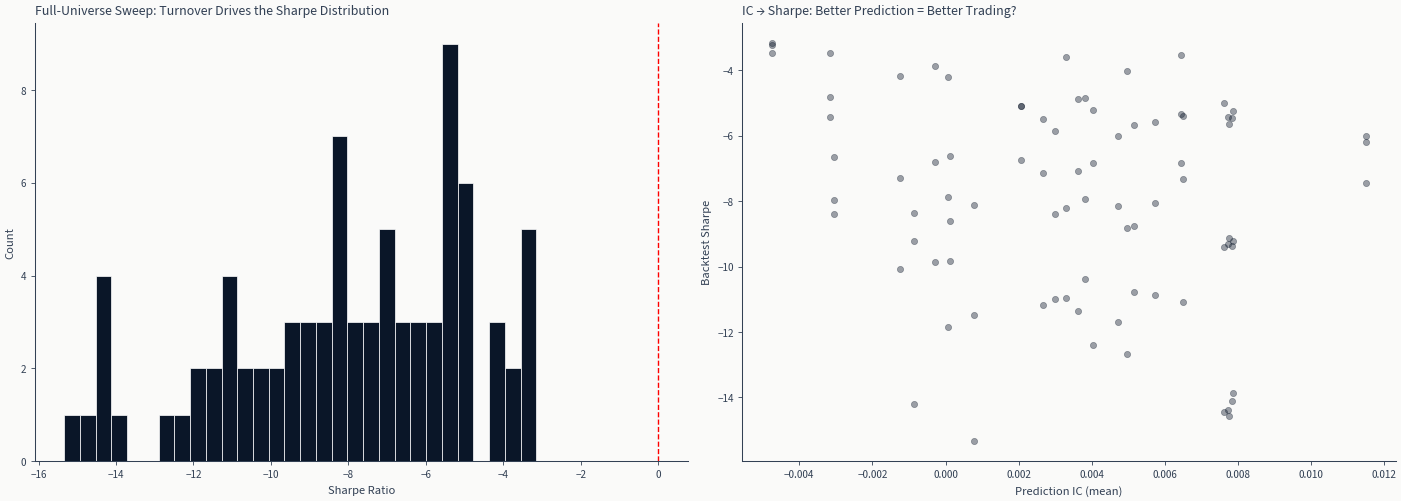

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe distribution histogram (full universe)
if not full_signal.is_empty():
    axes[0].hist(full_signal["sharpe"].to_numpy(), bins=30, edgecolor="white")
    axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[0].set_xlabel("Sharpe Ratio")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Full-Universe Sweep: Turnover Drives the Sharpe Distribution")

    # IC vs Sharpe
    axes[1].scatter(
        full_signal["ic_mean"].fill_null(0).to_numpy(),
        full_signal["sharpe"].to_numpy(),
        alpha=0.4,
        s=20,
    )
    axes[1].set_xlabel("Prediction IC (mean)")
    axes[1].set_ylabel("Backtest Sharpe")
    axes[1].set_title("IC → Sharpe: Better Prediction = Better Trading?")

# No `tight_layout()`: `matplotlibrc` sets the layout engine for every figure, so a second
# layout pass writes a warning into the render rather than improving it.
show_with_alt(
    fig,
    "Two panels side by side from the full-universe baseline sweep. Left: a 30-bin "
    "histogram of backtest Sharpe ratios, counts on the vertical axis and Sharpe on the "
    "horizontal, with a dashed red vertical line at zero. Right: a scatter of backtest "
    "Sharpe on the vertical axis against mean prediction IC on the horizontal, one "
    "translucent point per backtested configuration. The two panels answer the same "
    "question from opposite directions: how much of the Sharpe spread the histogram shows "
    "is accounted for by prediction quality.",
)

### Sharpe vs Trade Count Diagnostic

At 15-minute cadence, the relationship between Sharpe and trade count
reveals the cost dominance problem. Strategies with high trade counts
(active rebalancing) have deeply negative Sharpe because cost drag scales
linearly with the number of trades. The only configurations with positive
Sharpe are those with very few trades — either degenerate strategies
(near-constant predictions from DL models) or extreme concentration
(top_k=5 with infrequent position changes).

This diagnostic motivates the cadence × cost analysis in Ch18: reducing
the rebalance frequency is the structural solution to cost dominance.

The query below reads the full-universe runs only. Rows produced under the
screened universe are excluded so the relationship between trade count and
outcome is read on the unscreened baseline rather than on a mixture of the two.

In [16]:
db_path = CASE_DIR / "run_log" / "registry.db"
conn = sqlite3.connect(str(db_path))

trade_df = pl.read_database(
    """
    SELECT
        br.backtest_hash,
        bm.sharpe,
        bm.num_trades
    FROM backtest_runs br
    JOIN backtest_metrics bm ON br.backtest_hash = bm.backtest_hash
    WHERE br.stage = 'signal'
      AND json_extract(br.spec_json, '$.strategy.signal.universe_filter') IS NULL
    """,
    connection=conn,
    schema_overrides={"num_trades": pl.Float64, "sharpe": pl.Float64},
)
conn.close()

trade_df = trade_df.drop_nulls("num_trades")
print(f"Signal-stage backtests with trade data: {len(trade_df)}")
print(f"Trade count range: {trade_df['num_trades'].min():.0f} — {trade_df['num_trades'].max():.0f}")
print(f"Median trades: {trade_df['num_trades'].median():.0f}")

Signal-stage backtests with trade data: 120
Trade count range: 486 — 83389
Median trades: 13107


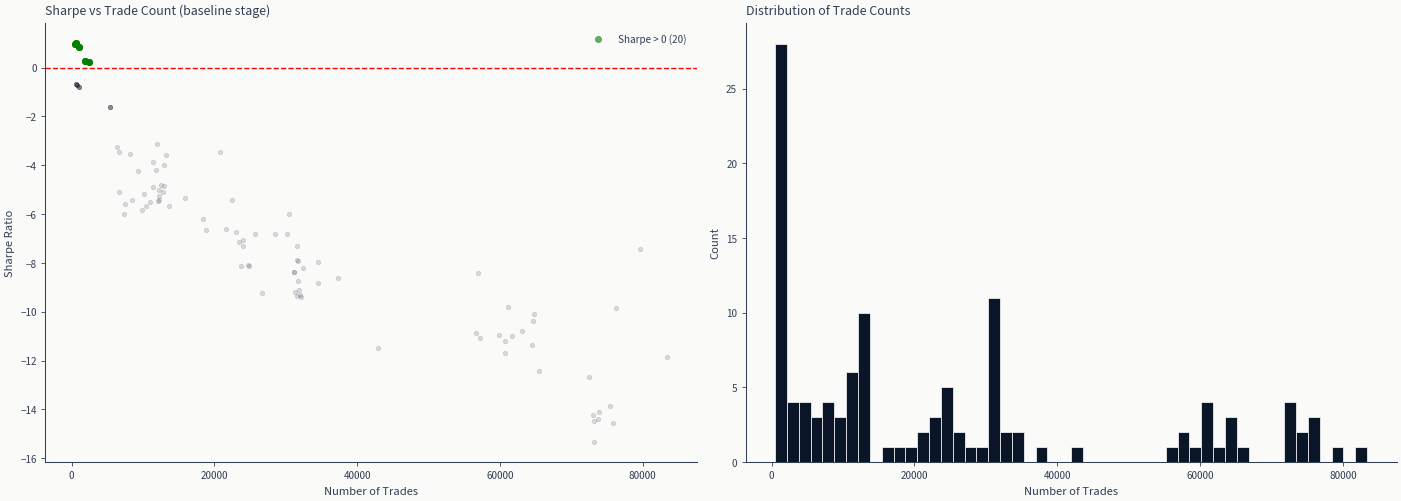


Positive-Sharpe backtests: 20 / 120 (16.7%)
  Median trades (positive Sharpe): 1069
  Median trades (all): 13107
  → Positive Sharpe strategies trade 12.3x less


In [17]:
if not trade_df.is_empty():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: Sharpe vs trades
    axes[0].scatter(
        trade_df["num_trades"].to_numpy(),
        trade_df["sharpe"].to_numpy(),
        alpha=0.15,
        s=10,
    )
    axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[0].set_xlabel("Number of Trades")
    axes[0].set_ylabel("Sharpe Ratio")
    axes[0].set_title("Sharpe vs Trade Count (baseline stage)")

    # Highlight: positive Sharpe only
    positive = trade_df.filter(pl.col("sharpe") > 0)
    if not positive.is_empty():
        axes[0].scatter(
            positive["num_trades"].to_numpy(),
            positive["sharpe"].to_numpy(),
            color="green",
            alpha=0.6,
            s=20,
            label=f"Sharpe > 0 ({len(positive)})",
        )
        axes[0].legend()

    # Histogram: trade count distribution
    axes[1].hist(trade_df["num_trades"].to_numpy(), bins=50, edgecolor="white")
    axes[1].set_xlabel("Number of Trades")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Distribution of Trade Counts")

    # See the note on the figure above: the layout engine is set repository-wide.
    show_with_alt(
        fig,
        "Two panels side by side. Left: a scatter of backtest Sharpe on the vertical axis "
        "against number of trades on the horizontal, one translucent grey point per "
        "backtested configuration, with a dashed red horizontal line at zero Sharpe and "
        "the configurations above zero redrawn in green and counted in the legend. Right: "
        "a 50-bin histogram of the same trade counts, counts on the vertical axis. Read "
        "the horizontal position of the green points against the bulk of the histogram.",
    )

    # Summary: positive-Sharpe strategies are low-trade
    if not positive.is_empty():
        print(
            f"\nPositive-Sharpe backtests: {len(positive)} / {len(trade_df)} "
            f"({len(positive) / len(trade_df):.1%})"
        )
        print(f"  Median trades (positive Sharpe): {positive['num_trades'].median():.0f}")
        print(f"  Median trades (all): {trade_df['num_trades'].median():.0f}")
        print(
            f"  → Positive Sharpe strategies trade "
            f"{trade_df['num_trades'].median() / max(positive['num_trades'].median(), 1):.1f}x less"
        )

A prediction that changes little from bar to bar triggers few position changes,
and so pays little in spread, whatever its ordering quality. That is model
smoothness standing in for a decision about how often to trade, and it is not a
decision anyone made. `17_costs` makes it explicitly, by sweeping the rebalance
cadence itself.

## 4. The Cost-Feasible Carrier (Act 2)

Act 1 established that ranking across all 113 names and rebalancing every bar
is cost-defeated. Act 2 applies the **cost-feasibility screen** from the
feasibility analysis (restrict to the cost-feasible universe — the
cheapest-to-trade names, frozen per split) and replaces every-bar rebalancing
with a turnover-controlled **slot mechanism**: a fixed number of concurrent
positions (slots), each entered when its signal clears a rolling per-symbol
percentile gate and held to a maximum horizon, displaced only by fresher
signals. The book then trades on composition changes rather than re-ranking
every bar. See `case_studies/utils/slot_strategy.py` for the mechanism.

The design shown here fixes the number of concurrent slots, the maximum time a
position may be held, the percentile a signal must clear to enter, and the exit
rule. The grid those four were chosen from runs on the screened universe only,
which is also the universe the chosen design is read on: a mechanism whose
purpose is to cut the cost of trading a cost-expensive tail has nothing to
choose between on a panel that still contains the tail. These backtests are
registered under `universe_filter='cost_feasible'` and are queried directly.

### The forecast the chapter carries

The strategy this chapter ends on does not trade one model. It trades the mean
of every regularized LightGBM forecast in the study - twelve configurations,
three losses across four leaf counts - as a single ordering.

That object has to be built before it can be traded, and it is built here. The
members are resolved from what is registered rather than listed, each enters at
its last checkpoint, and the average is registered as a prediction set of its
own under `family='ensemble'`. Everything downstream then reads it exactly the
way it reads a model: the backtest below, the holdout notebooks, and the
cross-case-study comparison in `20_strategy_analysis`.

Averaging is not a way of getting a better forecast, and normally it does not
produce one. What it produces is a forecast nobody chose. The rule that picks
it is fixed before the validation window is read, so the validation result is
a measurement of that rule rather than the best of the twelve results it could
have reported.

Its last checkpoint and not its best one, for the same reason: a checkpoint
chosen on validation is a choice made on the window the result is then read on.

In [18]:
_ens = load_ensemble_declaration(CASE_STUDY_ID)
ensemble_prediction_hash = None
if _ens is None:
    print("No ensemble declared for this case study.", flush=True)
elif EXECUTION_TIER != "canonical":
    # A preview training spec has to identity-cover its reductions, and this one has no
    # reductions of its own to cover - it is an average of whatever the members are. The
    # ensemble is a canonical-tier object; a preview run reads the canonical registry's
    # rows if they are there and otherwise leaves Section 4's ensemble line empty.
    print(f"Ensemble skipped: it is a canonical-tier object and this run is {EXECUTION_TIER}.")
else:
    # The pool the sweep actually ran on, so the two stages agree by construction rather
    # than by comment. This used to pass `_admissible`, which is the catalog filter -
    # complete and not retired - computed before `prediction_members_in_force` narrowed
    # the pool on publication and cross-sectional coverage. On the 2026-09-13 run that gap
    # was 784 catalog rows against 162 swept, so an unpublished or undercovered member
    # could have entered the ensemble while the sweep refused to backtest it, and
    # publishing the ensemble would have carried it downstream anyway.
    #
    # Degenerate sets are excluded on top, because the sweep has no degeneracy filter of
    # its own and a constant forecast averaged into a mean is not a weaker member - it is
    # a fixed offset. Four L1-linear sets in this registry hold two distinct forecast
    # values across 8,006,995 rows.
    _eligible = SWEPT_POOL - degenerate_prediction_hashes(CASE_DIR)
    _members = resolve_members(
        CASE_DIR,
        label=LABEL,
        family=str(_ens["member_family"]),
        split=SPLIT,
        max_num_leaves=int(_ens["max_num_leaves"]),
        admissible=_eligible,
    )
    _member_spec_json = sqlite3.connect(
        f"file:{CASE_DIR / 'run_log' / 'registry.db'}?mode=ro", uri=True
    )
    try:
        _row = _member_spec_json.execute(
            "SELECT spec_json FROM training_runs WHERE training_hash = ?",
            (_members["training_hash"][0],),
        ).fetchone()
    finally:
        _member_spec_json.close()
    _member_spec = json.loads(_row[0])
    _task = (_member_spec.get("computation", {}).get("task") or {}).get("type")

    if _task != "regression":
        # Averaging class scores is a different construction from averaging forecasts - it
        # needs the class values and the continuous column the classes were cut from, and
        # the registry asks for both. The featured carrier is a continuous label, so the
        # construction is not built rather than guessed at.
        print(
            f"Ensemble skipped for {LABEL}: its {_ens['member_family']} members are "
            f"{_task} models, and a mean forecast is defined here for regression only.",
            flush=True,
        )
    else:
        print(
            f"Ensemble members ({_members.height}, {_ens['member_family']} at "
            f"<= {_ens['max_num_leaves']} leaves, last checkpoint):",
            flush=True,
        )
        for _m in _members.iter_rows(named=True):
            print(
                f"  {_m['config_name']:22} leaves {_m['num_leaves']:>3}  "
                f"checkpoint {_m['checkpoint_value']}",
                flush=True,
            )

        _spec = ensemble_training_spec(
            _row[0],
            members=_members,
            method=str(_ens["method"]),
            config_name=str(_ens["config_name"]),
            provenance={
                "entry_point": "case_studies.utils.ensemble",
                "notebook_path": "14_backtest",
                "member_family": str(_ens["member_family"]),
            },
        )
        _ens_training_hash = register_training_run(
            CASE_STUDY_ID, _spec, case_dir=CASE_DIR, entry_point="14_backtest.py"
        )
        _averaged = mean_forecast(CASE_STUDY_ID, _members["prediction_hash"].to_list())
        ensemble_prediction_hash = register_prediction_set(
            CASE_STUDY_ID,
            _ens_training_hash,
            checkpoint_kind="final",
            checkpoint_value=None,
            split=SPLIT,
            predictions=_averaged,
            expected_keys=_averaged.select("fold_id", "symbol", "timestamp"),
            label=LABEL,
            case_dir=CASE_DIR,
        )
        # Registration is not publication, and selection asks the second question. An
        # identity is selectable only where the population its producer publishes still
        # lists it - `selectable_validation_candidates` tests membership, not exclusion -
        # so a prediction set no population ever named is invisible to the ranking however
        # complete it is. Every model notebook publishes one; this is the ensemble's.
        #
        # Named per label because this notebook runs per label and a population is
        # immutable once written. A population is idempotent under its own hash, so a
        # re-run of an unchanged ensemble re-opens the one it published rather than
        # writing a second generation.
        #
        # `supersedes` is the other half, and it is not optional here the way it is for a
        # notebook whose population changes only when someone edits it. This population's
        # single member is a hash over the members' forecasts, so any refit upstream - one
        # gbm configuration re-fitted, a checkpoint schedule changed, a feature artifact
        # rebuilt - gives the ensemble a new prediction identity. `create` refuses changed
        # membership under an existing name without being told what it replaces, so the
        # publish would raise before the backtest below on the first upstream refit, and the
        # previous generation would stay in force. `SUPERSEDES_LIVE` resolves to whatever
        # generation is in force, which is right in all three cases the resolver documents:
        # nothing on a clean clone, the same population on an unchanged re-run, and the tip
        # on a refit.
        _population_name = f"{CASE_STUDY_ID}-ensemble-{LABEL}-{SPLIT}-v1"
        _population = OfficialPopulation.create(
            study,
            name=_population_name,
            member_kind="prediction",
            members=(ensemble_prediction_hash,),
            supersedes=population_supersedes(
                study, name=_population_name, declared=SUPERSEDES_LIVE
            ),
        )
        print(
            f"\nEnsemble registered: {ensemble_prediction_hash} "
            f"({_averaged.height:,} rows over {_averaged['fold_id'].n_unique()} folds), "
            f"published as {_population.name}",
            flush=True,
        )

Ensemble members (12, gbm at <= 31 leaves, last checkpoint):


  default_huber          leaves  31  checkpoint 500


  default_mae            leaves  31  checkpoint 500


  default_mse            leaves  31  checkpoint 500


  leaves_15_huber        leaves  15  checkpoint 500


...

  leaves_31_mse          leaves  31  checkpoint 500


  leaves_7_huber         leaves   7  checkpoint 500


  leaves_7_mae           leaves   7  checkpoint 500


  leaves_7_mse           leaves   7  checkpoint 500



Ensemble registered: 60eeb1ae7ded (8,006,995 rows over 2 folds), published as nasdaq100_microstructure-ensemble-fwd_ret_15m-validation-v1


The ensemble is backtested on one entry scheme and not on the grid. It is the
object the chapter carries rather than another candidate to choose among, and
the design it is carried on is the one the sweep above already settled.

In [19]:
if ensemble_prediction_hash is not None:
    _featured = _by_name.get(str(_ens["featured_scheme"]))
    if _featured is None:
        msg = (
            f"ensemble.featured_scheme names {_ens['featured_scheme']!r}, which "
            f"get_entry_schemes_for does not produce for {LABEL}. The declared slot grid "
            "and this name have to agree."
        )
        raise KeyError(msg)
    _signal = {
        "method": _featured["method"],
        "top_k": _featured.get("top_k", 20),
        "long_short": bt_config.long_short,
        "universe_filter": str(_ens["universe_filter"]),
    }
    _signal.update({k: v for k, v in _featured.items() if k not in ("name", "method")})
    _spec_bt = build_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        prices=prices,
        traded_universe=TRADED_UNIVERSE,
        prediction_hash=ensemble_prediction_hash,
        initial_cash=bt_config.initial_cash,
        chapter="ch16",
        label=LABEL,
        signal=_signal,
    )
    _result = run_backtest(
        CASE_STUDY_ID,
        ensemble_prediction_hash,
        _spec_bt,
        prices=prices,
        predictions=normalize_prediction_columns(
            read_predictions(CASE_STUDY_ID, ensemble_prediction_hash)
        ),
        label=LABEL,
        register=True,
        force_rebacktest=FORCE_REBACKTEST,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )
    print(
        f"Ensemble on {_featured['name']} / {_ens['universe_filter']}: "
        f"Sharpe {_result.metrics['sharpe']:+.3f}, "
        f"{_result.metrics.get('num_trades', 0):.0f} trades",
        flush=True,
    )

  SKIP backtest (complete (hash=21bea99089c6)) — reusing cached result
Ensemble on slot_l_lq90_s10_h480_noexit_b210 / cost_feasible: Sharpe +0.566, 1487 trades


In [20]:
conn = sqlite3.connect(str(db_path))
carrier = pl.read_database(
    """
    SELECT
        tr.family,
        tr.config_name,
        json_extract(br.spec_json, '$.strategy.signal.method')    AS method,
        json_extract(br.spec_json, '$.strategy.signal.max_slots')  AS slots,
        json_extract(br.spec_json, '$.strategy.signal.long_q')     AS entry_q,
        json_extract(br.spec_json, '$.strategy.signal.top_k')      AS top_k,
        bm.sharpe,
        bm.num_trades
    FROM backtest_runs br
    JOIN backtest_metrics bm ON br.backtest_hash = bm.backtest_hash
    JOIN prediction_sets ps ON br.prediction_hash = ps.prediction_hash
    JOIN training_runs tr ON tr.training_hash = ps.training_hash
    WHERE br.stage = 'signal' AND ps.split = 'validation'
      AND json_extract(br.spec_json, '$.strategy.signal.universe_filter') = 'cost_feasible'
    ORDER BY bm.sharpe DESC
    """,
    connection=conn,
    schema_overrides={"sharpe": pl.Float64, "num_trades": pl.Float64},
)
conn.close()
print(carrier)

shape: (3_642, 8)
┌───────────────┬───────────────┬──────────────┬───────┬─────────┬───────┬────────────┬────────────┐
│ family        ┆ config_name   ┆ method       ┆ slots ┆ entry_q ┆ top_k ┆ sharpe     ┆ num_trades │
│ ---           ┆ ---           ┆ ---          ┆ ---   ┆ ---     ┆ ---   ┆ ---        ┆ ---        │
│ str           ┆ str           ┆ str          ┆ i64   ┆ f64     ┆ i64   ┆ f64        ┆ f64        │
╞═══════════════╪═══════════════╪══════════════╪═══════╪═════════╪═══════╪════════════╪════════════╡
│ gbm           ┆ default_multi ┆ slot_persist ┆ 5     ┆ 0.9     ┆ 20    ┆ 2.415932   ┆ 900.0      │
│               ┆ class         ┆ ent_signal_e ┆       ┆         ┆       ┆            ┆            │
│               ┆               ┆ xit          ┆       ┆         ┆       ┆            ┆            │
│ deep_learning ┆ nlinear       ┆ slot_persist ┆ 20    ┆ 0.99    ┆ 20    ┆ 2.300125   ┆ 3165.0     │
│               ┆               ┆ ent_signal_e ┆       ┆         ┆       

### The Slot Mechanism Clears the Cost Barrier

The table below puts the featured slot design next to the equal-weight top-k
baseline on the *same* screened universe, so the two differ only in when they
trade. What to read off it is the trade count first and the Sharpe second: the
slot book holds a fixed number of positions and replaces one only when a fresher
signal displaces it, so it trades a fraction of what re-ranking every bar does.
Whether that is enough to clear the cost barrier is the measurement, and it is
printed rather than described here.

In [21]:
slot_design = carrier.filter(
    (pl.col("method") == "slot_persistent_signal_exit")
    & (pl.col("slots") == 10)
    & (pl.col("entry_q") == 0.9)
)
gbm_slots = slot_design.filter(pl.col("family") == "gbm")
ensemble_slot = slot_design.filter(pl.col("family") == "ensemble")
eqw = carrier.filter(pl.col("method") == "equal_weight_top_k").sort("top_k")

print("Featured slot design (10 / 8h / 0.90 / hold-only), single gbm models:")
if not gbm_slots.is_empty():
    print(
        f"  models: {gbm_slots.height}  "
        f"Sharpe range {gbm_slots['sharpe'].min():+.2f} .. {gbm_slots['sharpe'].max():+.2f}  "
        f"mean {gbm_slots['sharpe'].mean():+.2f}"
    )
else:
    print("  models: 0 (carrier not present in this registry)")
if not ensemble_slot.is_empty():
    print(
        f"  ENSEMBLE (mean forecast of the {gbm_slots.height} gbm): "
        f"Sharpe {ensemble_slot['sharpe'][0]:+.3f}  "
        f"trades {ensemble_slot['num_trades'][0]:.0f}"
    )
# One line per top_k, not per backtest. `eqw` holds every equal-weight cell on the
# screened universe - one per (prediction set x top_k), which was 781 models at each of
# three top_k values on 2026-09-13 - and iterating it printed all 2,343 under a heading
# promising three lines. The comparison the heading makes is between the slot design and a
# top_k, so what belongs on a top_k's line is the distribution of that arm across the
# models that ran it.
print("\nEqual-weight top-k on the same screened universe (Act-1 echo):")
_eqw_by_k = (
    eqw.group_by("top_k")
    .agg(
        n=pl.len(),
        sharpe_max=pl.col("sharpe").max(),
        sharpe_median=pl.col("sharpe").median(),
        trades_median=pl.col("num_trades").median(),
    )
    .sort("top_k")
)
for r in _eqw_by_k.iter_rows(named=True):
    print(
        f"  top_{int(r['top_k']):<2}: {r['n']:>5} models  "
        f"Sharpe median {r['sharpe_median']:+.3f}  best {r['sharpe_max']:+.3f}  "
        f"trades (median) {r['trades_median']:.0f}"
    )

Featured slot design (10 / 8h / 0.90 / hold-only), single gbm models:
  models: 72  Sharpe range -3.77 .. +2.29  mean -0.80
  ENSEMBLE (mean forecast of the 72 gbm): Sharpe +0.566  trades 1487

Equal-weight top-k on the same screened universe (Act-1 echo):
  top_5 :   781 models  Sharpe median -5.908  best +1.326  trades (median) 19148
  top_10:   781 models  Sharpe median -8.801  best +1.463  trades (median) 56619
  top_20:   781 models  Sharpe median -12.458  best +1.467  trades (median) 88390


### What an ensemble of forecasts is for

Averaging the forecasts of several models of one family produces a single
ordering that no one model determines. Across a grid this size, where the
outcomes span a wide band and the differences between neighbouring
configurations are within what noise can produce, the ordering of that band is
not reliable enough to bet on: the configuration at the top of a validation
window is not dependably the one that leads on a later window.

The ensemble does not aim to sit above that band, and normally will not. What
it removes is the need to pick a member of it. That is worth having when the
ranking within the band is unstable, and worth nothing when one configuration
is genuinely better on grounds the validation window can establish.

The comparison below sets the ensemble against the single configuration with
the highest validation outcome in the screened set. A thin configuration
holding few positions is the one most exposed to this instability, because
fewer positions mean each one contributes more of the result.

In [22]:
schematic = carrier.filter(
    (pl.col("family") == "linear") & (pl.col("method") == "slot_persistent_signal_exit")
).sort("sharpe", descending=True)
if not schematic.is_empty():
    # The heading names one configuration, so one is printed. This used to loop over the
    # whole frame - 288 rows on the 2026-09-13 registry - under that heading, which made
    # the maximum unfindable and left the count it was drawn from unstated. The count is
    # what the comparison below needs: a maximum over 288 draws is not the same claim as a
    # maximum over three.
    _top = schematic.row(0, named=True)
    print(
        f"Highest validation outcome among the {schematic.height} screened linear "
        f"configurations: linear {int(_top['slots'])}-slot, validation Sharpe "
        f"{_top['sharpe']:+.3f}"
    )
    if schematic.height > 1:
        _rest = schematic["sharpe"].slice(1)
        print(
            f"  the other {_rest.len()} run from {_rest.min():+.3f} to {_rest.max():+.3f}, "
            f"median {_rest.median():+.3f}"
        )

Highest validation outcome among the 288 screened linear configurations: linear 5-slot, validation Sharpe +1.062
  the other 287 run from +0.508 to +1.062, median +0.694


### Deflated Sharpe on the Cost-Feasible Carrier

The selection-bias question — after K configurations were tried, does the
leader have skill? — is answered on the cost-feasible carrier cohort
(`cohort_metrics`, written by the uncertainty backfill). Effective trials are
small here because the configuration search (which slot count, hold, entry,
exit) was conducted upstream on the full universe; the screened registry
carries the chosen design across models plus contrasts, not the full grid.
The DSR therefore reflects selection over the model family at the fixed design,
not the full config search — a caveat the synthesis chapter makes explicit.

In [23]:
conn = sqlite3.connect(str(db_path))
dsr_cohorts = pl.read_database(
    """
    SELECT cohort_type, family, k_variants,
           n_trials_effective_er, dsr_er, dsr_er_pvalue, leader_sharpe
    FROM cohort_metrics
    ORDER BY cohort_type, family
    """,
    connection=conn,
)
conn.close()
print(dsr_cohorts)

shape: (0, 7)
┌─────────────┬────────┬────────────┬─────────────────────┬────────┬───────────────┬───────────────┐
│ cohort_type ┆ family ┆ k_variants ┆ n_trials_effective_ ┆ dsr_er ┆ dsr_er_pvalue ┆ leader_sharpe │
│ ---         ┆ ---    ┆ ---        ┆ er                  ┆ ---    ┆ ---           ┆ ---           │
│ null        ┆ null   ┆ null       ┆ ---                 ┆ null   ┆ null          ┆ null          │
│             ┆        ┆            ┆ null                ┆        ┆               ┆               │
╞═════════════╪════════╪════════════╪═════════════════════╪════════╪═══════════════╪═══════════════╡
└─────────────┴────────┴────────────┴─────────────────────┴────────┴───────────────┴───────────────┘


## Key Takeaways

1. **Check the machinery before reading the results.** A random signal put
   through the same engine should not produce a profitable strategy. That test
   catches lookahead in the fill timing, a misaligned join and a cost model
   that never charges, none of which are visible in a sweep's output.

2. **Turnover is a strategy decision, not an implementation detail.** The same
   ordering traded two ways produces two different results, because one rule
   reacts to every change in the ranking and the other only to changes large
   enough to displace a held position. At a short rebalancing interval the
   difference between them can exceed the difference between models.

3. **Ranking quality does not map onto traded outcome.** A prediction that
   orders the cross-section well can still lose money, because the score says
   nothing about how often the ordering changes, how liquid the names it
   favours are, or what it costs to act on it.

4. **Restricting the universe and controlling turnover are separate levers.**
   Running the same comparison on the screened universe with both trading
   rules shows which of the two is doing the work, and neither can be credited
   from a single result that changed both at once.

5. **An ensemble buys stability, not strength.** Averaging across a family's
   forecasts removes the need to bet on which member generalises. It is not a
   way to exceed the band, and reading it as one inverts what it is for.

6. **The top of a large grid is partly chance.** Nothing in this notebook
   selects a configuration. Selection happens once, under a stated rule, and
   the holdout is read once after it.

**Next:** The allocation notebook (Ch17) carries the cost-feasible carrier
through portfolio sizing; the cost notebook (Ch18) quantifies the
full-vs-screened difference directly.